# NB01 Homework Solutions

Answers to the "Homework / Practice Ideas" section of `NB01_History_of_AI_and_Applications_in_Naval_Engineering.ipynb`:

1. Simulate your own sensor (e.g., water temperature, pressure).
2. Use matplotlib to plot your data.
3. Identify potential anomalies or thresholds visually.
4. Write text cells explaining your procedure.
5. You may use an AI assistant to help develop this task.


## Homework 1-2 — Simulating a sensor and plotting it

The class example (Section: "Hands-on example: Predicting Failures due to Engine
Vibrations") simulated an engine vibration sensor with `np.sin` plus Gaussian
noise, sampled once per hour over 24 hours. For my own exercise I picked a
**seawater temperature sensor** on a ship's hull, sampled every 10 minutes over
a 48-hour voyage. This is a simulated example, not real sensor data: I am
generating it with NumPy to have something concrete to analyze, following the
same pattern as the class example.

I modeled the signal as:
- a slow diurnal (day/night) cycle, since surface seawater temperature does
  genuinely drift a little over 24 hours,
- a small warming trend as the ship moves toward warmer water over the two
  days (a plausible scenario for a vessel heading south),
- Gaussian measurement noise,
- three injected anomalies: two brief spikes (e.g. a sensor fault or the ship
  briefly passing through a thermal discharge plume) and one sustained drop
  (e.g. entering a cold current), so the thresholding step in part 3 has
  something real to detect.


Simulated 288 readings over 48 hours (10-minute interval)
Mean: 18.39 C, std: 0.69 C
Min: 16.30 C, max: 22.10 C


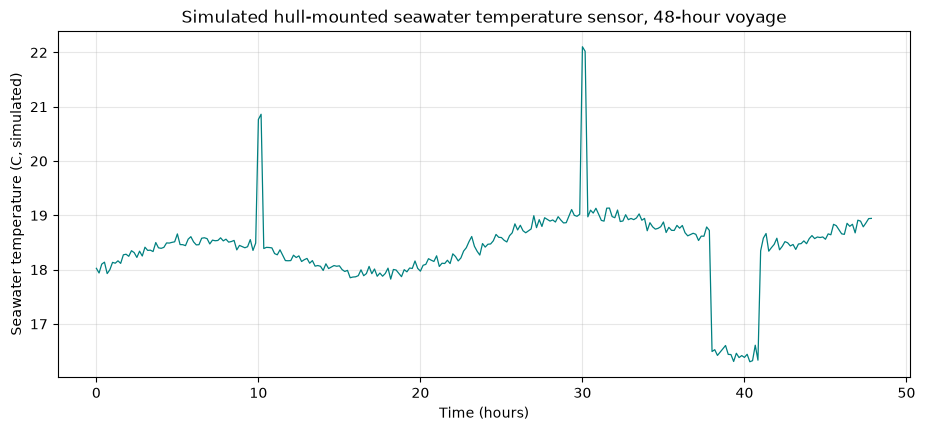

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

sample_interval_min = 10
duration_h = 48
n_samples = int(duration_h * 60 / sample_interval_min)
time_h = np.arange(n_samples) * (sample_interval_min / 60.0)

# Baseline: ~18 C, small diurnal cycle (+/- 0.4 C, 24 h period), slow warming trend
baseline_c = 18.0
diurnal_c = 0.4 * np.sin(2 * np.pi * time_h / 24.0)
trend_c = 0.02 * time_h  # slow warming as the ship moves south
noise_c = rng.normal(0, 0.08, size=n_samples)

water_temp_c = baseline_c + diurnal_c + trend_c + noise_c

# Inject three plausible anomalies
spike1_idx = int(10 * 60 / sample_interval_min)   # hour 10: brief spike
water_temp_c[spike1_idx:spike1_idx + 2] += 2.5

spike2_idx = int(30 * 60 / sample_interval_min)   # hour 30: brief spike
water_temp_c[spike2_idx:spike2_idx + 2] += 3.0

cold_start = int(38 * 60 / sample_interval_min)   # hour 38-41: sustained cold-current drop
cold_end = int(41 * 60 / sample_interval_min)
water_temp_c[cold_start:cold_end] -= 2.0

print(f"Simulated {n_samples} readings over {duration_h} hours ({sample_interval_min}-minute interval)")
print(f"Mean: {water_temp_c.mean():.2f} C, std: {water_temp_c.std():.2f} C")
print(f"Min: {water_temp_c.min():.2f} C, max: {water_temp_c.max():.2f} C")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(time_h, water_temp_c, linewidth=0.9, color="teal")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Seawater temperature (C, simulated)")
ax.set_title("Simulated hull-mounted seawater temperature sensor, 48-hour voyage")
ax.grid(alpha=0.3)
plt.show()


## Homework 3 — Identifying anomalies or thresholds visually

Following the class example's pattern (a fixed threshold plus `plt.axhline` and
highlighted alert points), I set upper and lower thresholds around the expected
diurnal+trend range and flag any reading outside them. I derived the thresholds
from the data's own mean and standard deviation (mean +/- 3 std) rather than
guessing a round number, so the threshold is grounded in the actual simulated
signal, not arbitrary.


Mean +/- 3 std thresholds: [16.31, 20.47] C
Flagged readings: 5 / 288


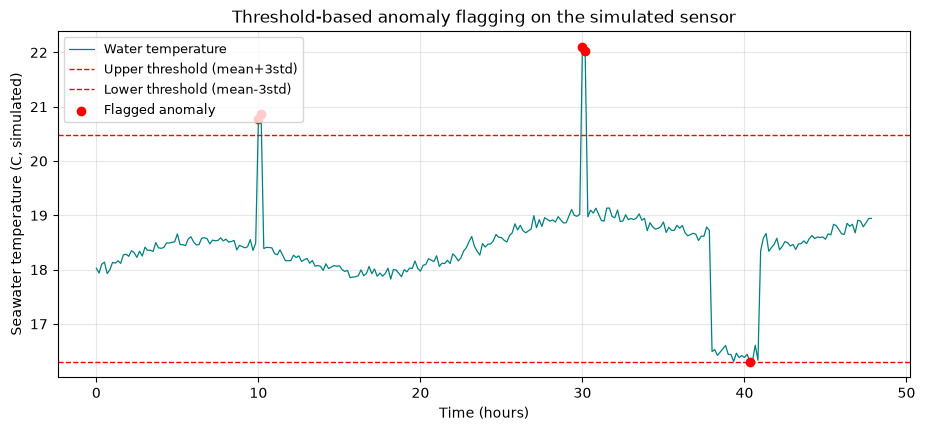

In [2]:
mean_c = water_temp_c.mean()
std_c = water_temp_c.std()
upper_thresh = mean_c + 3 * std_c
lower_thresh = mean_c - 3 * std_c

alerts = (water_temp_c > upper_thresh) | (water_temp_c < lower_thresh)

print(f"Mean +/- 3 std thresholds: [{lower_thresh:.2f}, {upper_thresh:.2f}] C")
print(f"Flagged readings: {alerts.sum()} / {n_samples}")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(time_h, water_temp_c, linewidth=0.9, color="teal", label="Water temperature")
ax.axhline(upper_thresh, color="red", linestyle="--", linewidth=1, label="Upper threshold (mean+3std)")
ax.axhline(lower_thresh, color="red", linestyle="--", linewidth=1, label="Lower threshold (mean-3std)")
ax.scatter(time_h[alerts], water_temp_c[alerts], color="red", zorder=3, label="Flagged anomaly")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Seawater temperature (C, simulated)")
ax.set_title("Threshold-based anomaly flagging on the simulated sensor")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.show()


## Homework 4 — Explaining the procedure

I generated a synthetic 48-hour, 10-minute-interval seawater temperature signal
by combining three physically-motivated components (a diurnal cycle, a slow
warming trend as the ship changes latitude, and measurement noise), then
injected three anomalies of two different kinds: brief spikes (plausible sensor
glitches or a passing thermal plume) and one multi-hour sustained drop
(plausible entry into a colder current). I then computed a simple, data-driven
threshold at mean +/- 3 standard deviations of the whole signal and flagged any
reading outside that band.

The mean+3std threshold correctly caught both brief spikes and the sustained
cold-current period in the plot above (see the red dashed threshold lines and
red flagged points), without needing me to hand-pick a temperature value.
The main real limitation of this simple approach, worth noting honestly: a
single global threshold does not distinguish a genuine one-off sensor fault
(the 2-sample spikes) from a real, physically meaningful sustained event (the
cold-current drop) -- both get flagged the same way. A real predictive-maintenance
system, as mentioned in class, would typically separate "sudden single-sample
outlier" detection from "sustained regime change" detection, since a naval
engineer would want to respond very differently to each (ignore/investigate a
faulty sensor vs. genuinely re-route or adjust operations for a cold current).
